In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os, sys

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.metrics import eval_metrics_2d


In [345]:
def compare_metrics(dataframes, labels):
    
    
    # Headers
    header = f"{'Metric':<35} | " + " | ".join([f"{label[:15]:^12}" for label in labels])
    print(header)
    print("-" * 95)
    
    # GEt data
    all_metrics = []
    for df in dataframes:
        # extract
        pred_traj = np.column_stack((df['pred_x'], df['pred_y'], df['pred_theta']))
        gt_traj = np.column_stack((df['gt_x'], df['gt_y'], df['gt_theta']))
        # calc materics
        res = eval_metrics_2d(pred_traj, gt_traj) 
        all_metrics.append(res)
    
    # Kkeys
    metrics_display = {
        "Total Trajectory Length [m]": ("distance", "{:12.4f}"),
        "Total Rotation Length [rad]": ("rotation", "{:12.4f}"),
        "ATE (Absolute Traj. Err) [m]": ("ate_rmse", "{:12.4f}"),
        "Final Position Drift [m]": ("final_drift_m", "{:12.4f}"),
        "RTE (Relative Trans. Err) [%]": ("rte_perc", "{:12.2f}"),
        "ARE (Absolute Rot. Err) [rad]": ("are_rmse", "{:12.4f}"),
        "Final Rotation Drift [rad]": ("final_rot_drift", "{:12.4f}"),
        "RRE (Relative Rot. Err) [%]": ("rre_perc", "{:12.2f}")
    }

    print("\n" + "=" * 95)
    print(f"{'Odometry Evaluation Metrics - Comparison':^95}")
    print("=" * 95)
        
    
    for display_name, (dict_key, fmt) in metrics_display.items():
        if "Total" in display_name:
            print("-" * 95) 
            
        row_str = f"{display_name:<35} | "
        for metrics in all_metrics:
            val = metrics.get(dict_key, 0.0)
            row_str += fmt.format(val) + " | "
        print(row_str[:-3])
        
    print("=" * 95 + "\n")

In [346]:
def compare_trajectory_2d(dataframes, labels):
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    
    # gt
    gt_df = dataframes[0]
    ax.plot(gt_df['gt_x'], gt_df['gt_y'], label='Rzeczywista (GT)', 
            color='black', linewidth=3, linestyle='--', zorder=10)
    
    # start
    ax.plot(gt_df['gt_x'].iloc[0], gt_df['gt_y'].iloc[0], label='Start', 
            color='green', marker='o', markersize=8, zorder=11, linestyle='None')
    
    # colors list
    colors = ['#d62728', '#1f77b4', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2']
    
    # draw trajectory
    for i, (df, label) in enumerate(zip(dataframes, labels)):
        color = colors[i % len(colors)]
        ax.plot(df['pred_x'], df['pred_y'], label=f'Pred: {label}', 
                color=color, linewidth=2, marker='.', markersize=4, zorder=5+i, alpha=0.8)

    # styles
    ax.minorticks_on()
    ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
    ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

#     ax.set_title('Zestawienie trajektorii odometrii sonarowej (2D)', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Oś X [m]', fontsize=12, labelpad=10)
    ax.set_ylabel('Oś Y [m]', fontsize=12, labelpad=10)
    ax.set_aspect('equal', adjustable='box') # force equal proportions

    ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

    plt.tight_layout()
    plt.show()

In [347]:
def compare_trajectory_3d(dataframes, labels):
  
    fig = go.Figure()
    
    #  get gt
    gt_df = dataframes[0]
    
    # get depth 
    z_gt = gt_df['depth'] if 'depth' in gt_df.columns and not gt_df['depth'].isna().all() else np.zeros_like(gt_df['gt_x'])

    # gt
    fig.add_trace(go.Scatter3d(
        x=gt_df['gt_x'],
        y=gt_df['gt_y'],
        z=z_gt,
        mode='lines',
        name='Rzeczywista (GT)',
        line=dict(color='black', width=6, dash='dash')
    ))
    
    # start pt
    fig.add_trace(go.Scatter3d(
        x=[gt_df['gt_x'].iloc[0]],
        y=[gt_df['gt_y'].iloc[0]],
        z=[z_gt.iloc[0]],
        mode='markers',
        name='Start',
        marker=dict(color='green', size=8)
    ))

    # color list 
    plotly_colors = ['red', 'blue', 'orange', 'purple', 'cyan']

    # trajectories
    for i, (df, label) in enumerate(zip(dataframes, labels)):
        z_pred = df['depth'] if 'depth' in df.columns and not df['depth'].isna().all() else np.zeros_like(df['pred_x'])
        color = plotly_colors[i % len(plotly_colors)]
        
        fig.add_trace(go.Scatter3d(
            x=df['pred_x'],
            y=df['pred_y'],
            z=z_pred,
            mode='lines',
            name=f'Pred: {label}',
            line=dict(color=color, width=4)
        ))

    # setup layouts
    fig.update_layout(
        # title=dict(text="Zestawienie trajektorii odometrii (3D)", font=dict(size=18)),
        scene=dict(
            xaxis_title='X [m]',
            yaxis_title='Y [m]',
            zaxis_title='Z (Depth) [m]',
            aspectmode='manual',
            aspectratio=dict(x=1, y=1, z=0.4) # set flatten z to clearer view
        ),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            bgcolor="rgba(255, 255, 255, 0.8)"
        ),
        width=1000,
        height=700,
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

In [348]:
def quality_comparision(dataframes, labels):

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, dpi=100)
    colors = ['#d62728', '#1f77b4', '#ff7f0e', '#9467bd', '#8c564b']

    for i, (df, label) in enumerate(zip(dataframes, labels)):
        color = colors[i % len(colors)]
        frames = np.arange(len(df['confidence'])) / len(df['confidence']) * 100
     
        axs[0].plot(frames, df['confidence'], label=label, color=color, linewidth=1.5, alpha=0.8)
        axs[1].plot(frames, df['inliers_ratio'] * 100, label=label, color=color, linewidth=1.5, alpha=0.8) # *100 dla procentów

    # --- Confidence ---
    axs[0].set_title('Średnia ufność dopasowań', fontsize=13, fontweight='bold')
    axs[0].set_ylabel('Ufność [%]', fontsize=11)
    axs[0].legend(loc='best', frameon=True, facecolor='white', framealpha=0.9)
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # --- Inliers ---
    axs[1].set_title('Stosunek spójnych punków RANSAC do całkowitej liczby punktów', fontsize=13, fontweight='bold')
    axs[1].set_ylabel('[%]', fontsize=11)
    axs[1].set_xlabel('Przebyta trasa [%]', fontsize=11)
    axs[1].grid(True, linestyle='--', alpha=0.5)

    # Layout
    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
    plt.tight_layout()
    plt.show()

In [349]:
def estimation_deviation_compare(dataframes, labels):

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi=100)
    
   
    data_x = [df['est_std_x'].dropna() for df in dataframes]
    data_y = [df['est_std_y'].dropna() for df in dataframes]
    data_theta = [df['est_std_theta'].dropna() for df in dataframes]


    box_props = dict(patch_artist=True, boxprops=dict(facecolor='#1f77b4', color='black', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2), 
                     flierprops=dict(marker='.', markerfacecolor='gray', markersize=4, alpha=0.5))

    # --- Boxplot X ---
    axs[0].boxplot(data_x, labels=labels, **box_props)
    axs[0].set_title('Rozrzut w oknie: Oś X (Ruch w przód)', fontsize=12, fontweight='bold')
    axs[0].set_ylabel('Odchylenie standardowe [m]')

    # --- Boxplot Y ---
    axs[1].boxplot(data_y, labels=labels, **box_props)
    axs[1].set_title('Rozrzut w oknie: Oś Y (Ruch boczny)', fontsize=12, fontweight='bold')
    axs[1].set_ylabel('Odchylenie standardowe [m]')

    # --- Boxplot Yaw ---
    axs[2].boxplot(data_theta, labels=labels, **box_props)
    axs[2].set_title('Rozrzut w oknie: Kąt Yaw (Kierunek)', fontsize=12, fontweight='bold')
    axs[2].set_ylabel('Odchylenie standardowe [rad]')

    # Kosmetyka dla wszystkich subplotów
    for ax in axs:
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)
        ax.grid(False, axis='x')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Pochylenie etykiet, gdyby były zbyt długie
        ax.tick_params(axis='x', rotation=15)

    plt.suptitle('Porównanie spójności estymat wewnątrz okna czasowego', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

In [ ]:
def step_error_comparision(dataframes, labels):
   
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
    
    # --- Przygotowanie danych statystycznych ---
    # Błąd translacji (Euklidesowy błąd kroku z X i Y)
    trans_errors = [
        np.sqrt(df['err_step_dx']**2 + df['err_step_dy']**2).dropna() 
        for df in dataframes
    ]
    
    # Błąd rotacji (Absolutna wartość błędu zmiany kąta)
    rot_errors = [
        np.abs(df['err_step_dtheta']).dropna() 
        for df in dataframes
    ]

    # Ustawienia stylu dla wykresów pudełkowych (Boxplots)
    box_props = dict(
        patch_artist=True, 
        boxprops=dict(facecolor="#2ca02c", color='black', alpha=0.3), # Używamy np. zielonego tła
        medianprops=dict(color='red', linewidth=2), 
        flierprops=dict(marker='.', markerfacecolor='gray', markersize=4, alpha=0.5)
    )

    # --- Subplot 1: Błąd lokalnej translacji ---
    axs[0].boxplot(trans_errors, labels=labels, showfliers=False, **box_props) 
    axs[0].set_title('Względny lokalny błąd translacji', fontsize=13, fontweight='bold')
    axs[0].set_ylabel('Błąd przesunięcia 2D [m]', fontsize=11)

    # --- Subplot 2: Błąd lokalnej rotacji ---
    # Dodano showfliers=False
    axs[1].boxplot(rot_errors, labels=labels, showfliers=False, **box_props)
    axs[1].set_title('Względny lokalny błąd rotacji', fontsize=13, fontweight='bold')
    axs[1].set_ylabel('Błąd obrotu [rad]', fontsize=11)
    # Kosmetyka dla wszystkich subplotów
    for ax in axs:
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)
        ax.grid(False, axis='x')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Pochylenie etykiet na osi X, jeśli nazwy modeli są długie
        ax.tick_params(axis='x', rotation=15)

    # Główny tytuł
    plt.suptitle('Zestawienie stabilności lokalnej modeli (błąd na jeden krok)', 
                 fontsize=16, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

In [351]:
# root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
# seq_pth = 'SonarOdometryDataset/selfsupervised/val/seq_15'
# traj1_pth = os.path.join(root_dir, seq_pth, 'results/noise_comparie/eval_seq15_small_noise.csv')
# traj2_pth = os.path.join(root_dir, seq_pth, 'results/noise_comparie/eval_seq15_small_noise_artefacts.csv')
# traj3_pth = os.path.join(root_dir, seq_pth, 'results/noise_comparie/eval_seq15_mid_noise.csv')
# traj4_pth = os.path.join(root_dir, seq_pth, 'results/noise_comparie/eval_seq15_mid_noise_artefacts.csv')
# traj5_pth = os.path.join(root_dir, seq_pth, 'results/noise_comparie/eval_seq15_big_noise_big_artefacts.csv')

# traj1 = pd.read_csv(traj1_pth)
# traj2 = pd.read_csv(traj2_pth)
# traj3 = pd.read_csv(traj3_pth)
# traj4 = pd.read_csv(traj4_pth)
# traj5 = pd.read_csv(traj5_pth)

# labels = ['1', '2', '3', '4', '5']
# traj = [traj1, traj2, traj2, traj4, traj5]

In [352]:
root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
seq_pth = 'SonarOdometryDataset/supervised/val/seq_14'
traj1_pth = os.path.join(root_dir, seq_pth, 'results/eval_std_noise.csv')
traj2_pth = os.path.join(root_dir, seq_pth, 'results/eval_std_noise_nobackend.csv')
traj3_pth = os.path.join(root_dir, seq_pth, 'results/eval_std_noise_windowsize_5.csv')
traj4_pth = os.path.join(root_dir, seq_pth, 'results/eval_std_noise_smaller_step.csv')

traj1 = pd.read_csv(traj1_pth)
traj2 = pd.read_csv(traj2_pth)
traj3 = pd.read_csv(traj3_pth)
traj4 = pd.read_csv(traj4_pth)

labels = ['1', '2', '3', '4']
traj = [traj1, traj2, traj3, traj4]

In [353]:
compare_metrics(traj, labels)

Metric                              |      1       |      2       |      3       |      4      
-----------------------------------------------------------------------------------------------
                          Odometry Evaluation Metrics                           
Metric                              |         Absolute |    Relative [%]
--------------------------------------------------------------------------------
Total Trajectory Length             |       101.0650 m |               - 
Total Rotation Length               |      12.2939 rad |               - 
--------------------------------------------------------------------------------
Absolute Trajectory Err (ATE)       |         8.9180 m |         8.8240 %
Final Position Drift                |         7.1290 m |         7.0538 %
Relative Translation Err (RTE)      |         1.3069 m |       123.4924 %
--------------------------------------------------------------------------------
Absolute Rotation Err (ARE)         |    

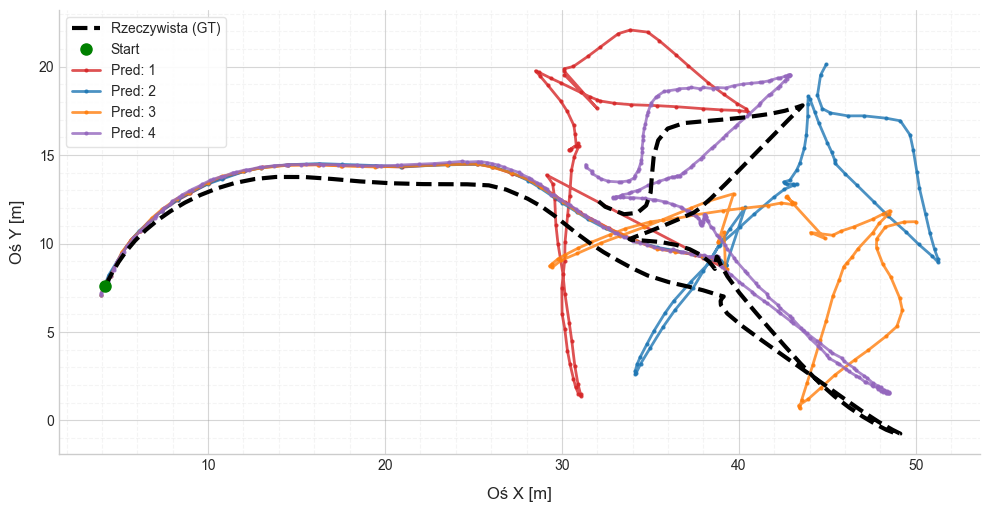

In [354]:
compare_trajectory_2d(traj, labels)

In [355]:
compare_trajectory_3d(traj, labels)

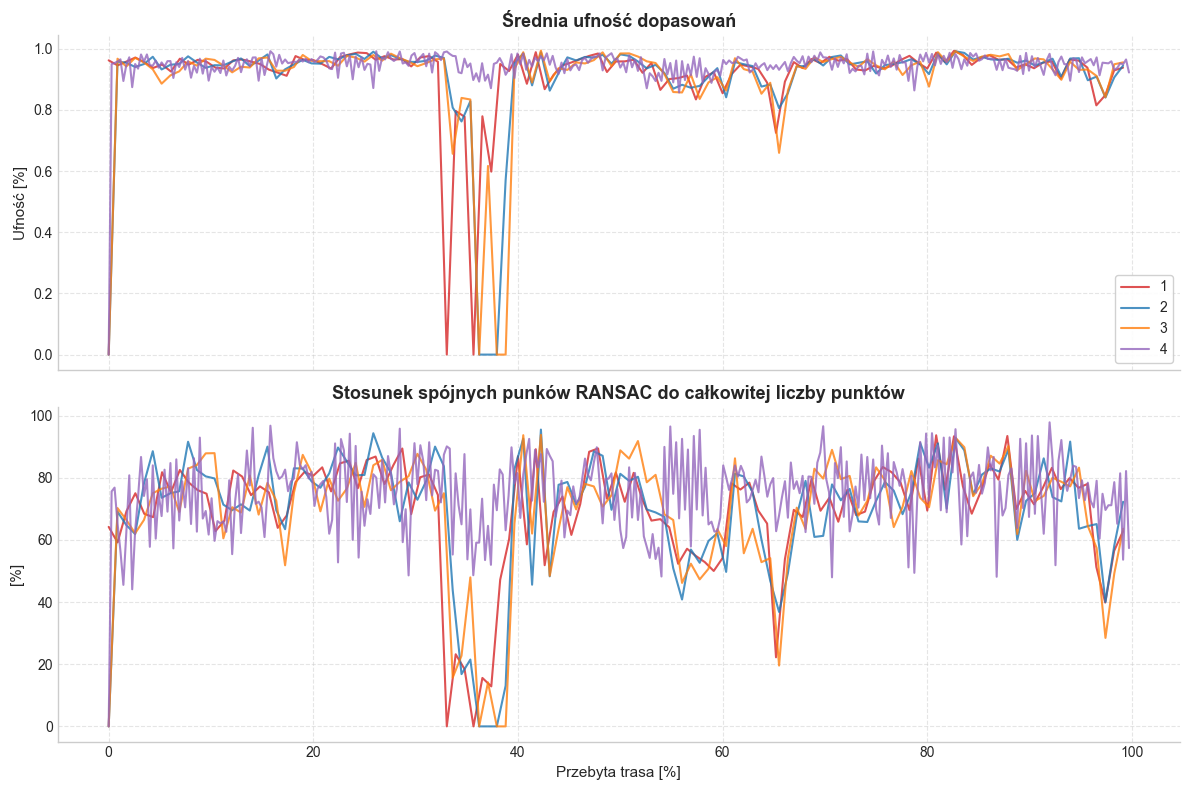

In [356]:
quality_comparision(traj, labels)

C:\Users\janis\AppData\Local\Temp\ipykernel_15900\1247804464.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot(trans_errors, labels=labels, showfliers=False, **box_props)
C:\Users\janis\AppData\Local\Temp\ipykernel_15900\1247804464.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot(rot_errors, labels=labels, showfliers=False, **box_props)


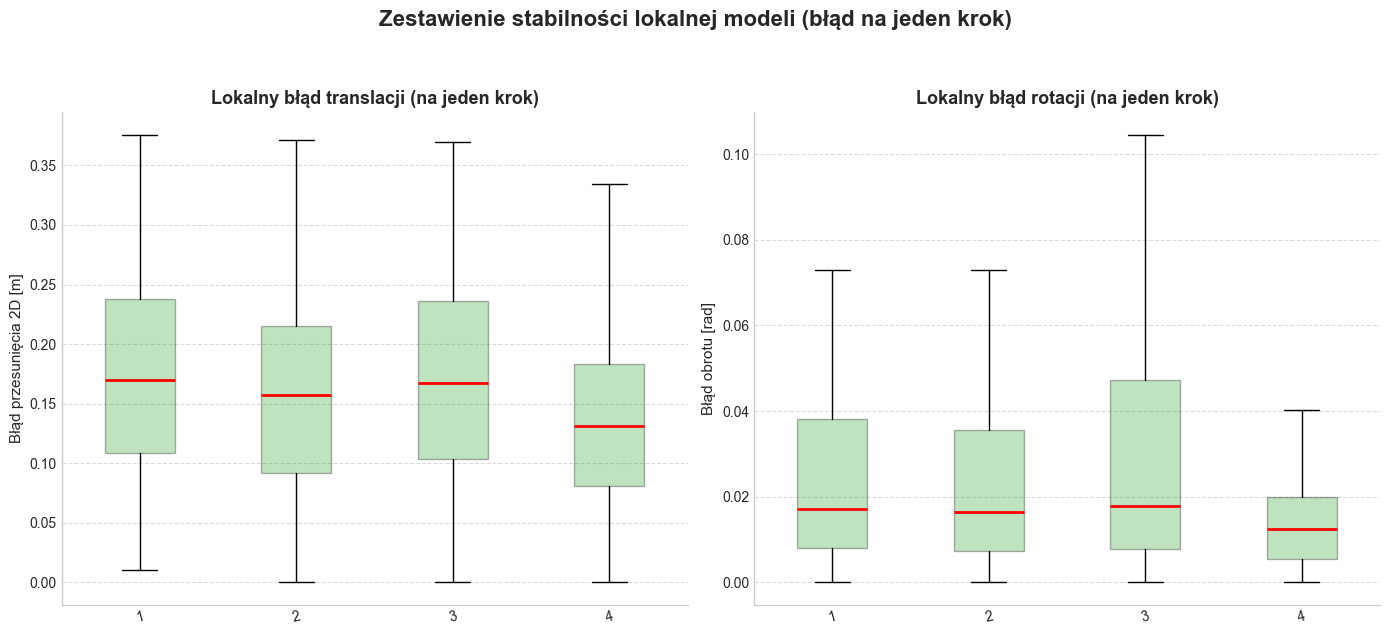

In [357]:
step_error_comparision(traj, labels)